In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx
#init_printing()

Problem 1

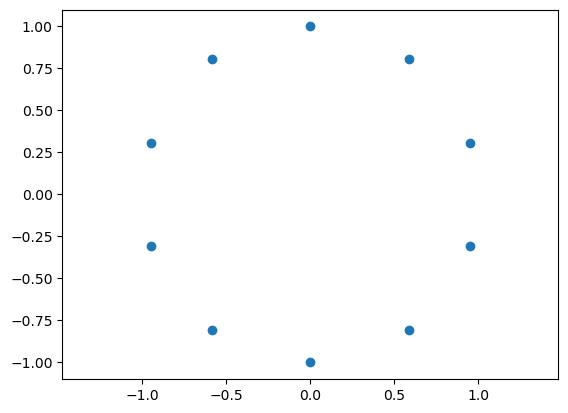

In [3]:
N = 10
theta = np.linspace(0,2*np.pi,N+1)[:N]
formation_x = np.sin(theta)
formation_y = np.cos(theta)
formation = np.asarray([formation_x,formation_y])
plt.scatter(formation_x,formation_y)
plt.axis("equal")
plt.show()

In [ ]:
def get_D_L(A):
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) # i LOVE list comprehensions, even though would probably be faster to do something like np.diag(A@np.ones(n))
    L = D-A
    return D,L

G = nx.cycle_graph(10)
A = nx.adjacency_matrix(G).toarray()

D,L = get_D_L(A)

w = np.zeros_like(A,float) # float is important or everything gets screwed up, rounded to ints
for i in range(N):
    for j in range(N):
        if i != j and A[i,j] == 1:
            w[i,j] = 1 / (1 + max(D[i,i], D[j,j]))
    w[i,i] = 1 - np.sum(w[i,:])  # diagonal ensures row sum = 1

sym.Matrix(w)

Matrix([
[0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0, 0.333333333333333],
[0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0],
[              0.0, 0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0],
[              0.0,               0.0, 0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0],
[              0.0,               0.0,               0.0, 0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0],
[              0.0,            

In [106]:
evals = np.sort(np.linalg.eigvals(w))
lambda_2 = evals[-2]

In [165]:
def DGD(x,p,formation,kmax,alpha):
    N = x.shape[1]
    x_list = [x.copy()]
    for k in range(kmax):
        x_prev = x.copy()
        for i in range(N):
            consensus_term = np.sum([w[i, j] * x_prev[:, j] for j in range(N)], axis=0)
            grad_i = x_prev[:, i] + formation[:, i] - p[:, i]
            x[:, i] = consensus_term - alpha(k) * grad_i
        x_list.append(x.copy())
    return x_list

def alpha_harm(k):
    return 1/(1+k)

def plot_trajectories(x_lst,x_star,title = "DGD Trajectories of Agents"):
    x_array = np.array(x_lst)
    N = x_array.shape[2]

    plt.figure(figsize=(7,6),dpi = 300)
    for i in range(N):
        traj = x_array[:,:,i]  # shape (kmax+1, 2)
        plt.plot(traj[:,0], traj[:,1],lw = 1)#, label=f'Agent {i+1}')

    plt.scatter(x_lst[0][0],x_lst[0][1], label = r"$x(0)$",zorder = 2,c = 'black',s = 10)
    plt.scatter(x_lst[-1][0],x_lst[-1][1], label = r"$x(k_{max})$",zorder = 2, facecolors='none', edgecolors='black',s=20)
    plt.scatter(x_star[0],x_star[1],label = r"$x^\star$",zorder=3,c ="red",marker="x" )
    plt.title(title)

    plt.grid()


    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.show()

def plot_final_pos(x_lst):
    plt.scatter(x_lst[-1][0],x_lst[-1][1])
    plt.axis('equal')

In [166]:
print("step size bound:",1- lambda_2)

step size bound: 0.12732200375003466


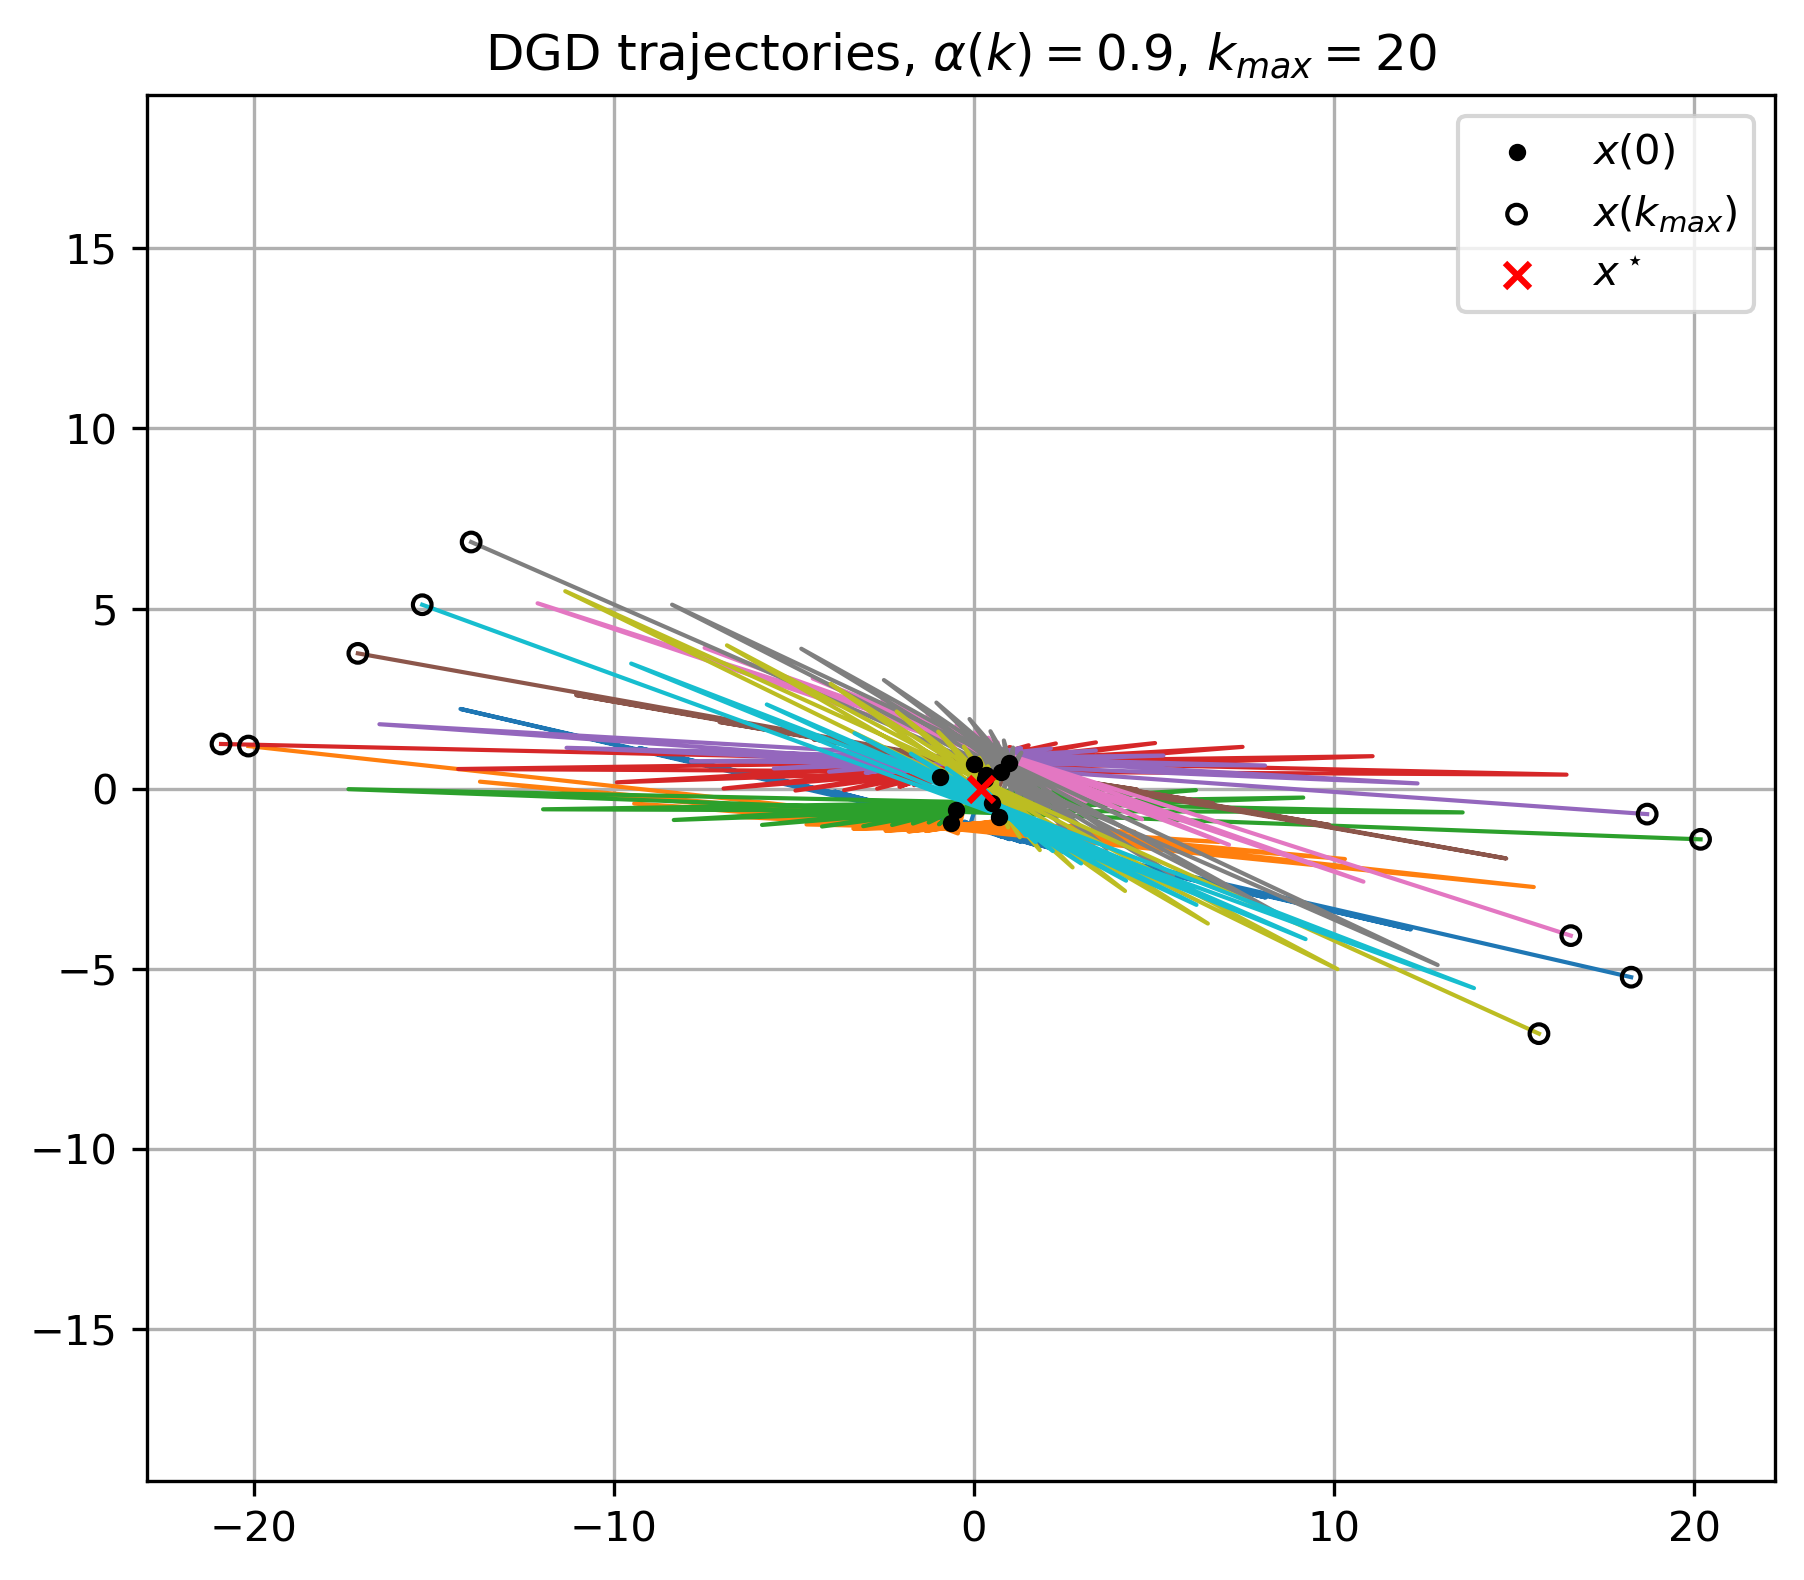

In [210]:
def alpha_const_1(k):
    return 0.9#1-lambda_2+0.2

np.random.seed(seed=18)
x = np.random.uniform(-1,1,(2,N))
p = np.random.uniform(-1,1,(2,N))
x_star = (1/N)*np.sum(p-formation,axis =1)
kmax = 20
xf = DGD(x,p,formation,kmax,alpha_const_1) 
plot_trajectories(xf,x_star,r"DGD trajectories, $\alpha(k) =0.9$, $k_{max}=20$")
#plot_final_pos(xf)


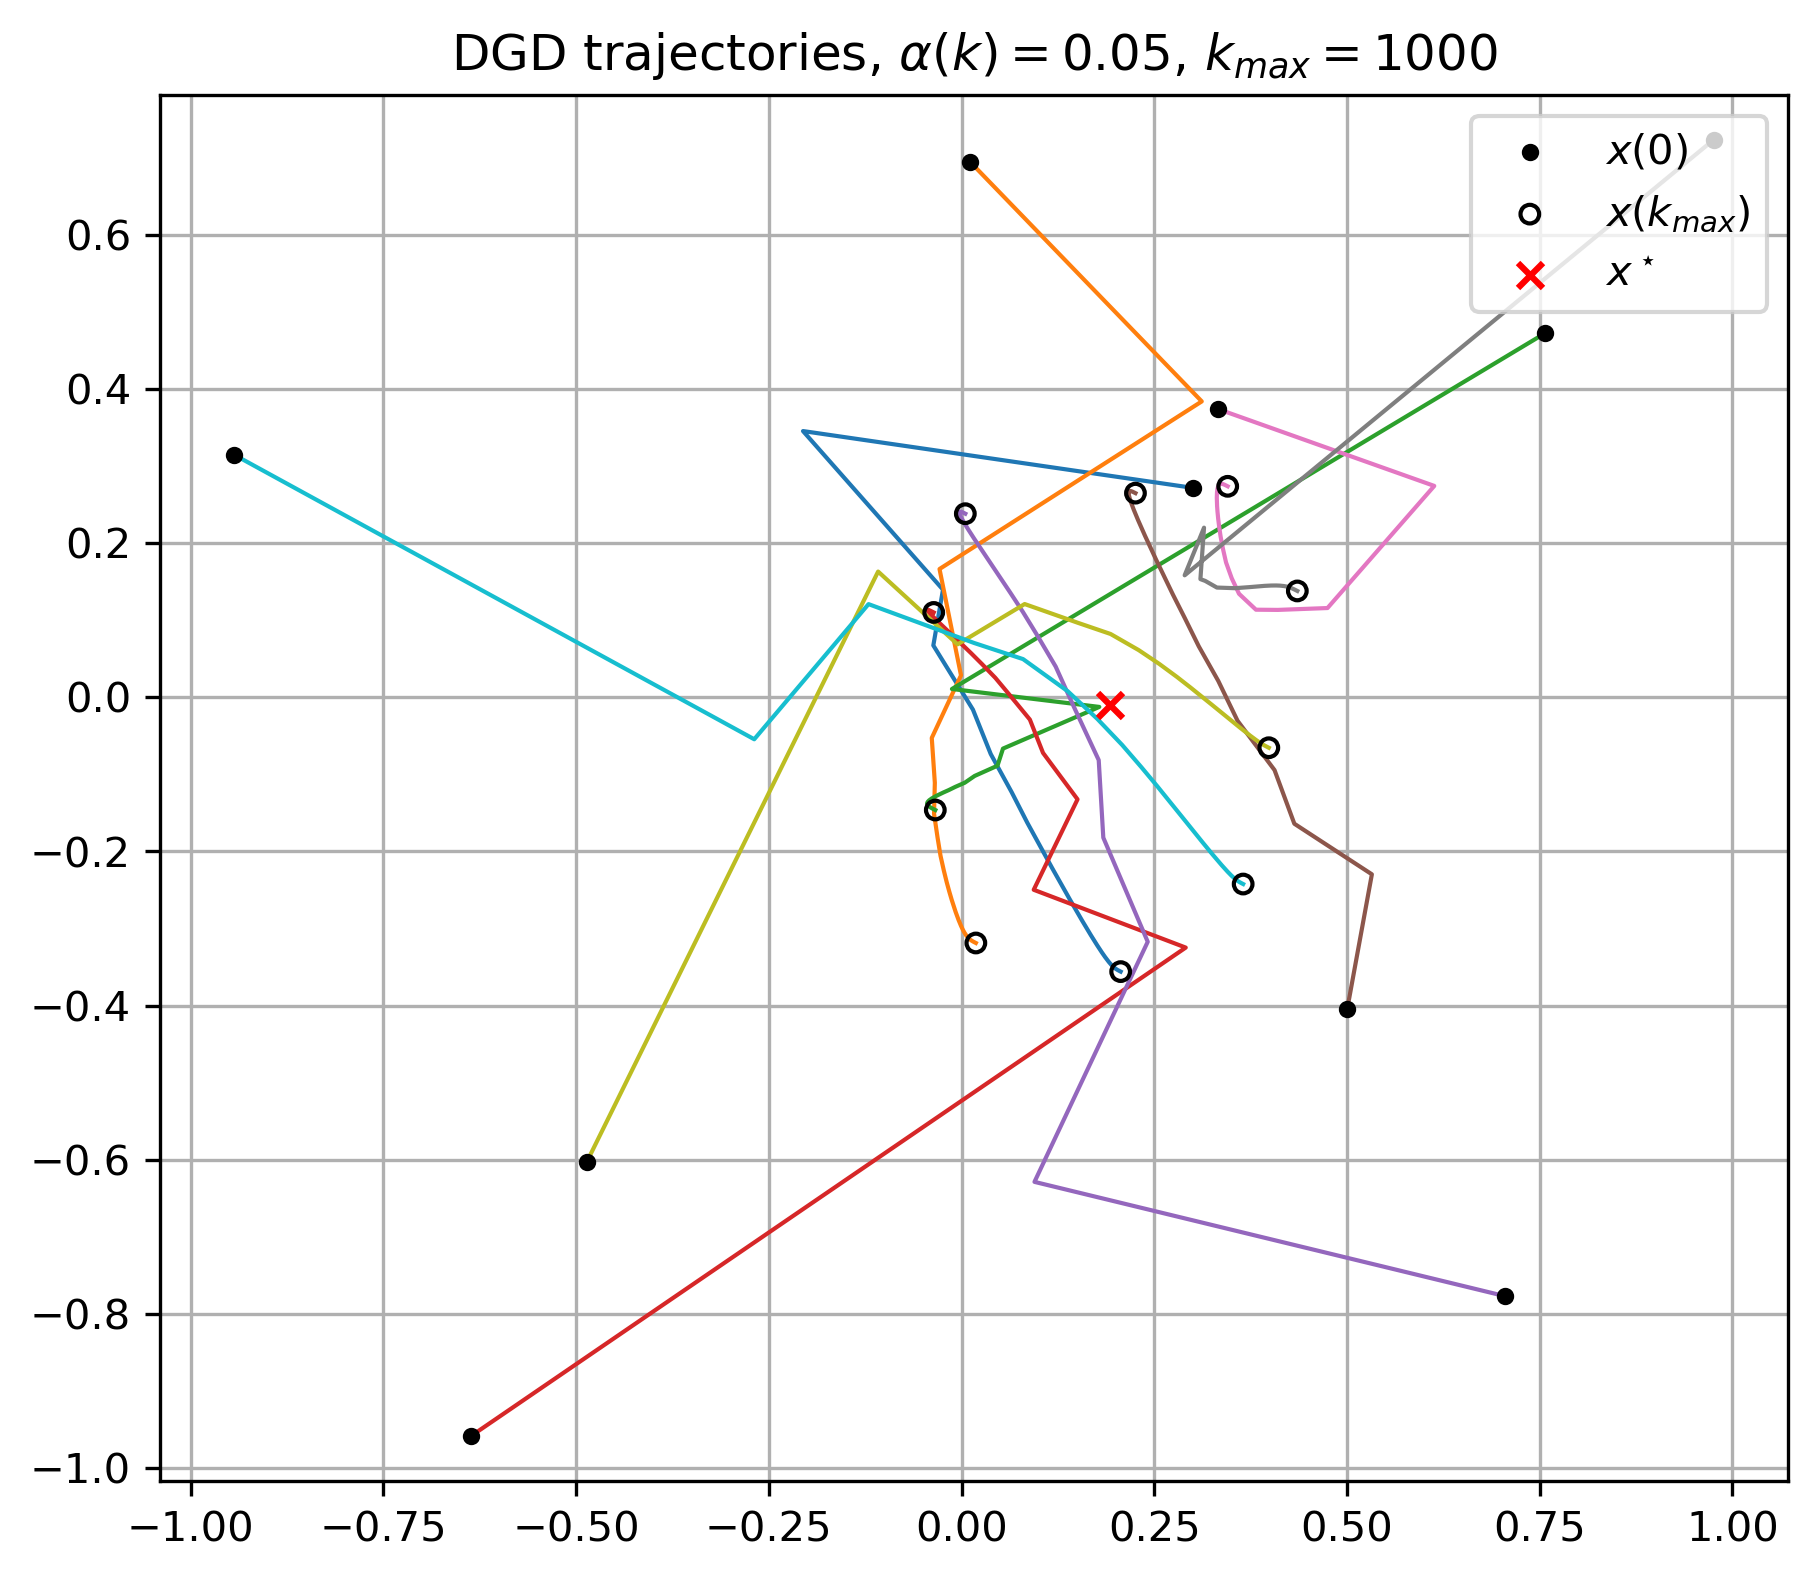

In [211]:
def alpha_const_2(k):
    return 0.05
np.random.seed(seed=18)
x = np.random.uniform(-1,1,(2,N))
p = np.random.uniform(-1,1,(2,N))
x_star = (1/N)*np.sum(p-formation,axis =1)
kmax = 1000
xf2 = DGD(x,p,formation,kmax,alpha_const_2) 
plot_trajectories(xf2,x_star,r"DGD trajectories, $\alpha(k) = 0.05$, $k_{max}=1000$")

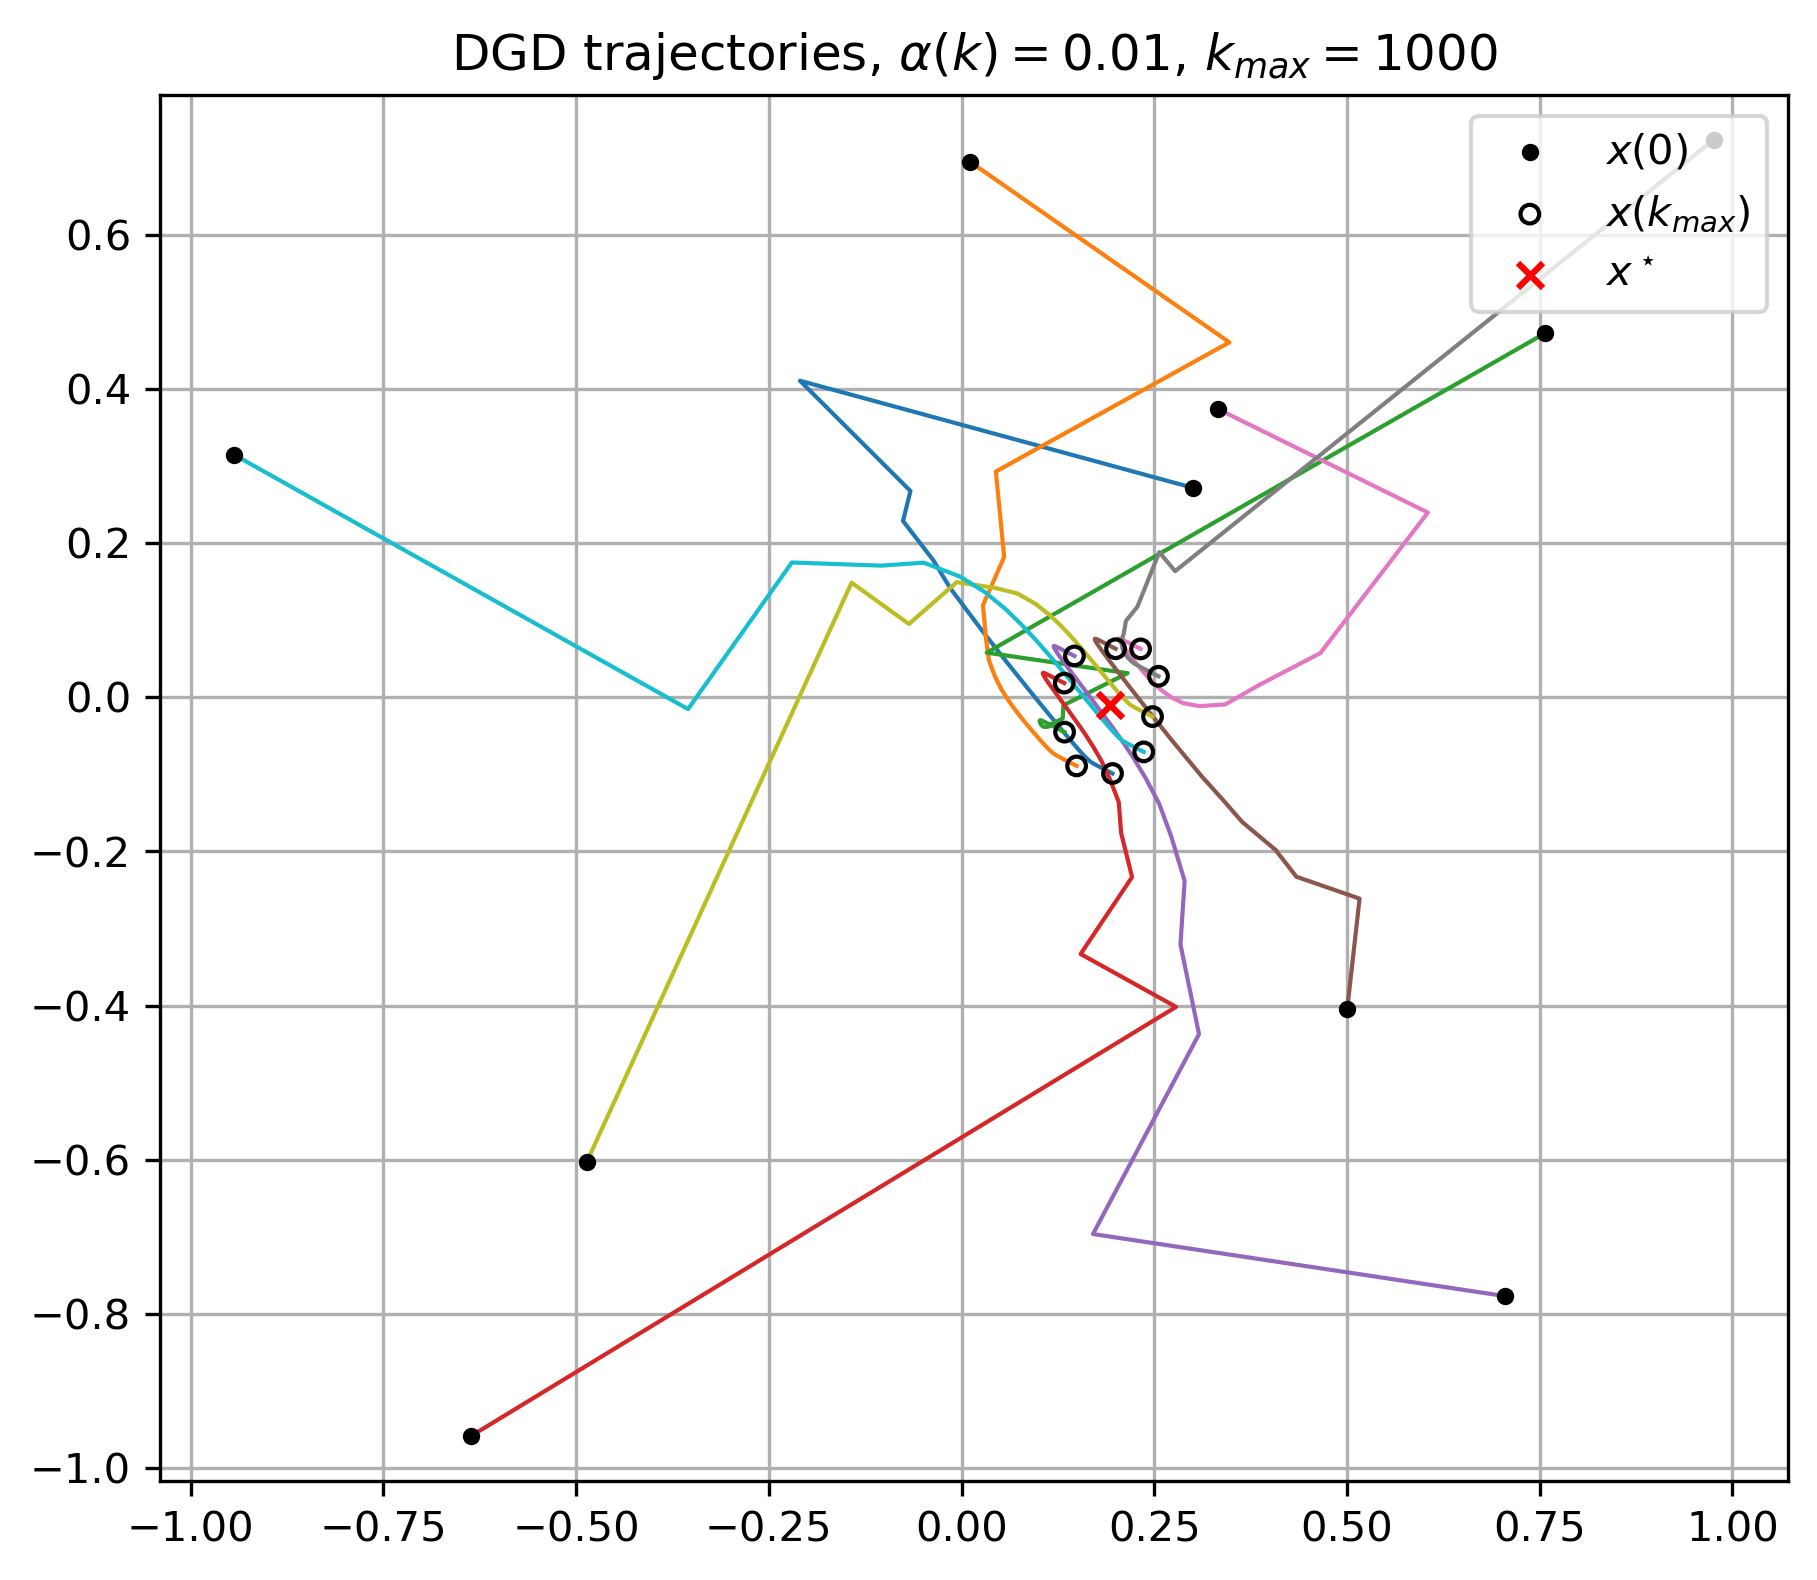

In [212]:
def alpha_const_3(k):
    return 0.01
np.random.seed(seed=18)
x = np.random.uniform(-1,1,(2,N))
p = np.random.uniform(-1,1,(2,N))
x_star = (1/N)*np.sum(p-formation,axis =1)
kmax = 1000
xf2 = DGD(x,p,formation,kmax,alpha_const_3) 
plot_trajectories(xf2,x_star,r"DGD trajectories, $\alpha(k) = 0.01$, $k_{max} = 1000$")

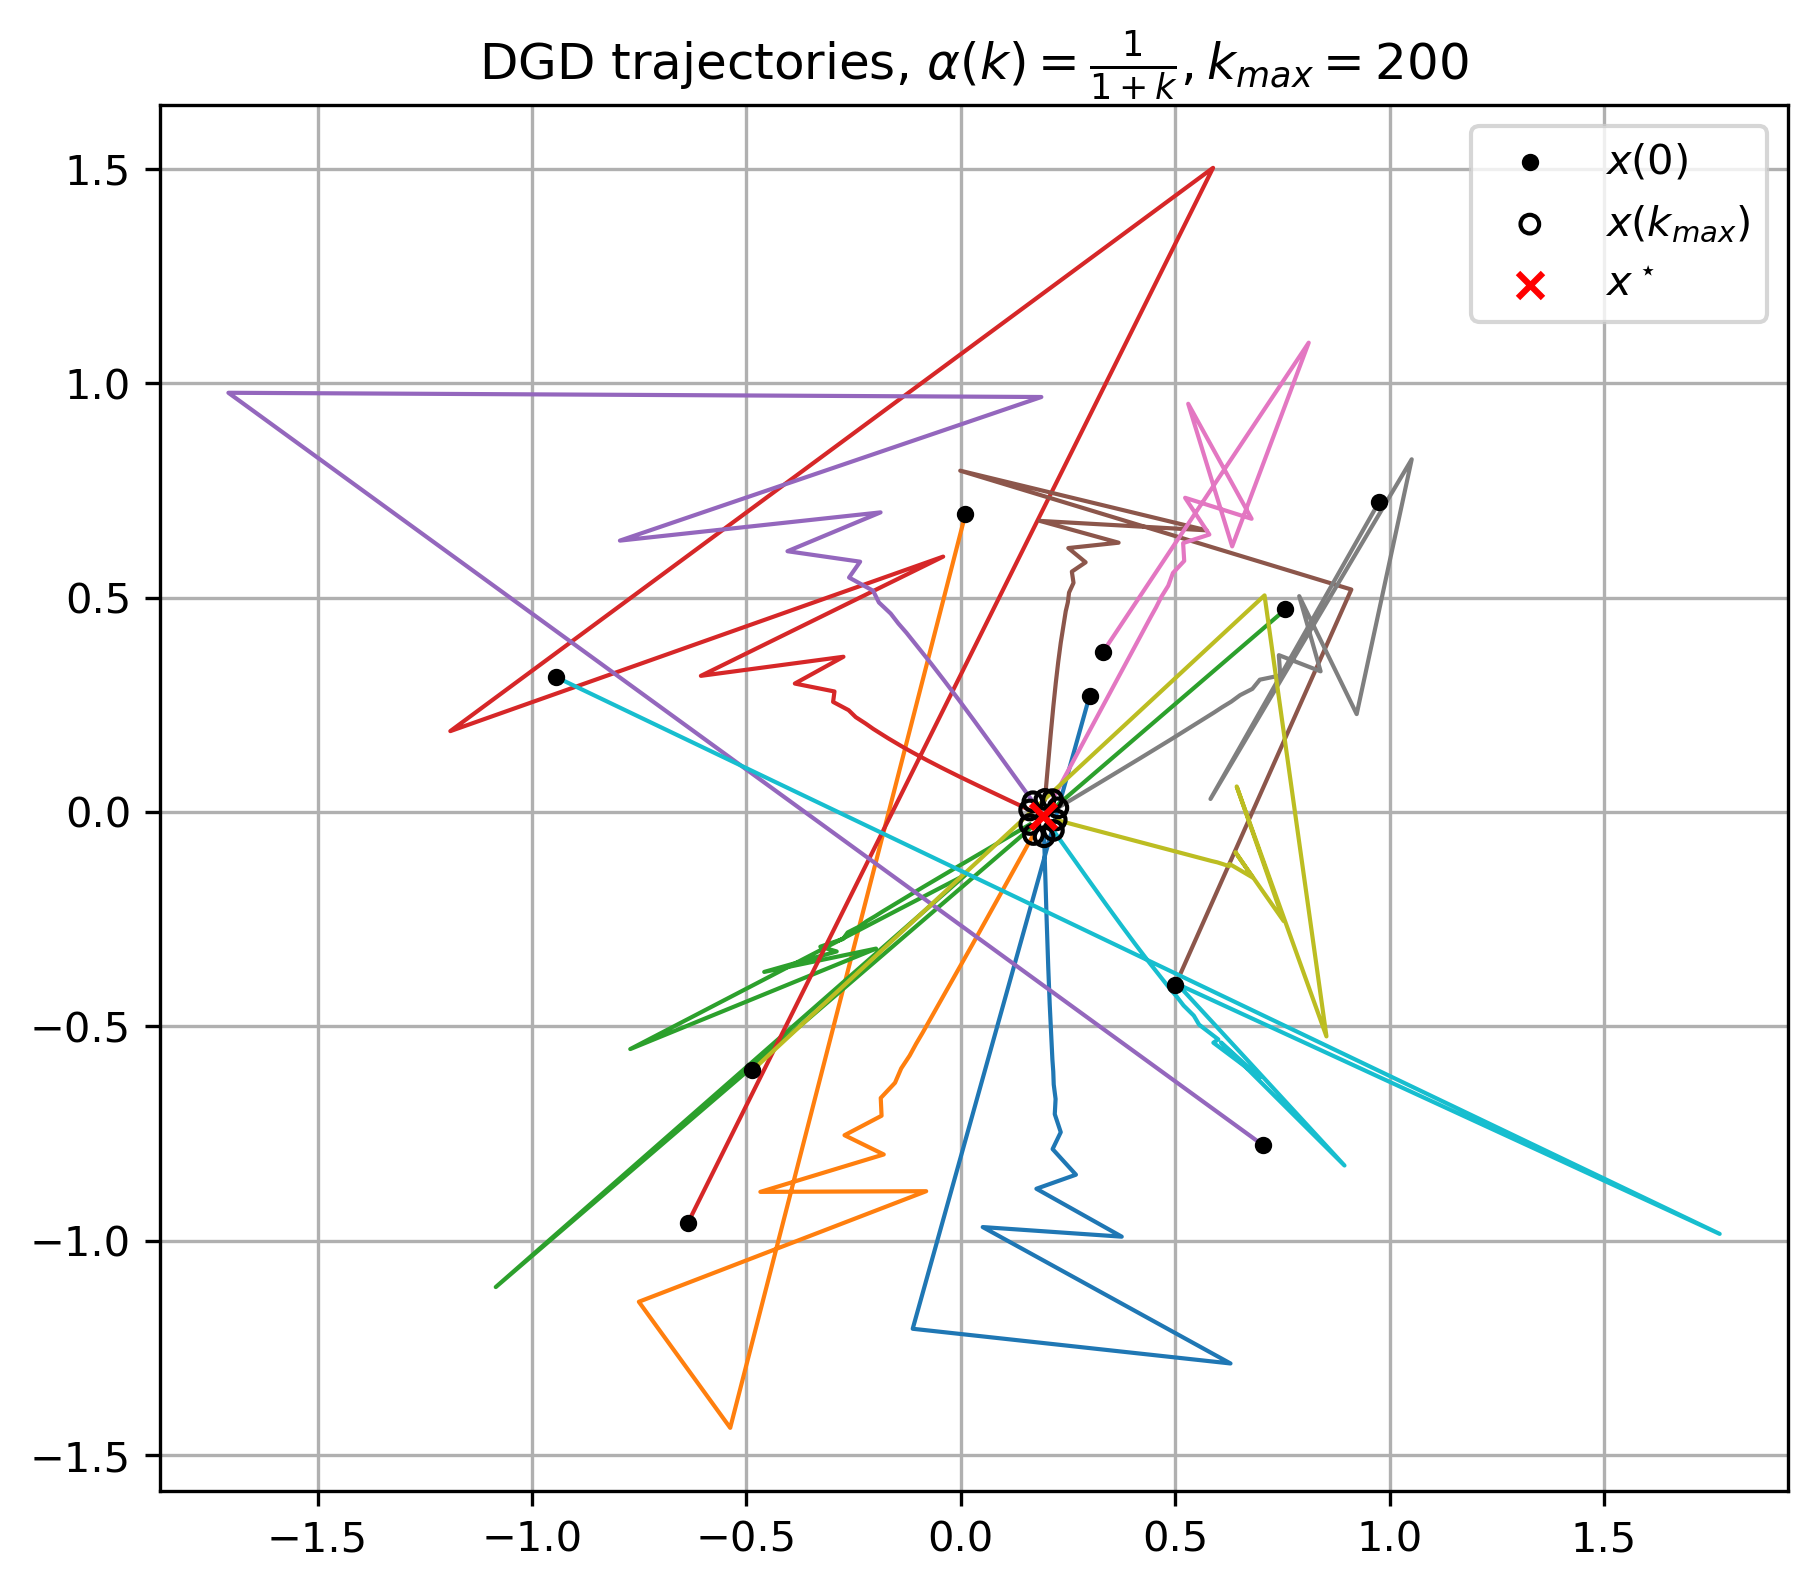

In [218]:
np.random.seed(seed=18)
x = np.random.uniform(-1,1,(2,N))
p = np.random.uniform(-1,1,(2,N))
x_star = (1/N)*np.sum(p-formation,axis =1)
kmax = 200
xf3 = DGD(x,p,formation,kmax,alpha_harm) 
plot_trajectories(xf3,x_star,r"DGD trajectories, $\alpha(k) = \frac{1}{1+k}, k_{max} = 200$")

(-2.7449119790911185,
 3.5497673594113714,
 -2.675262613281957,
 3.8020372886938616)

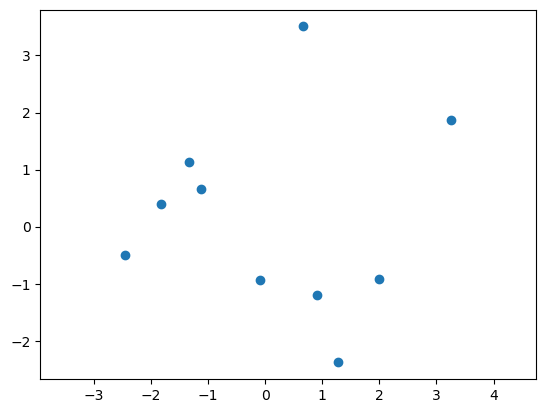

In [11]:
plt.scatter(xf[1][0],xf[1][1])
plt.axis("equal")